# 08 ? Tiny MLP Ablation

Physical sanity checks were completed in step 07. This notebook does not establish new physics and does not create or modify datasets. It tests a tiny MLP only as a small nonlinear ablation/control experiment for `E0` and `dE1` under structured LOAO/LOARO validation.

Ridge remains the preferred model unless the pre-registered success criteria are met. This notebook does not tune hyperparameters, does not use random train/test splits, does not use `dE2` as a main target, does not claim data efficiency, does not claim that an MLP discovered physics, and does not implement inverse design.

In [1]:
from __future__ import annotations

import csv
import math
import sys
import warnings
from collections.abc import Callable
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from sklearn.compose import TransformedTargetRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.model import build_baseline_model, make_ablation_feature_matrix

DATA_PATH = PROJECT_ROOT / "data" / "superellipse_discrete_n_dense_dataset.npz"
SUMMARY_PATH = PROJECT_ROOT / "reports" / "mlp_ablation_summary.csv"
PER_FOLD_PATH = PROJECT_ROOT / "reports" / "mlp_ablation_per_fold.csv"
SEED_STABILITY_PATH = PROJECT_ROOT / "reports" / "mlp_ablation_seed_stability.csv"
ASSET_DIR = PROJECT_ROOT / "reports" / "assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

N_VALUES = [1.2, 2.0, 3.0, 4.0]
TARGETS = ["E0", "dE1"]
PROTOCOLS = {
    "LOAO": "a",
    "LOARO": "aspect_ratio",
}
SEEDS = list(range(10))
MAIN_THRESHOLD_PERCENT = 15.0

plt.rcParams.update({
    "figure.figsize": (8.0, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")
print(f"Reports: {SUMMARY_PATH}, {PER_FOLD_PATH}, {SEED_STABILITY_PATH}")
print(f"Asset directory: {ASSET_DIR}")

Project root: D:\Diplom Physcis ML\Diplom Physcis ML
Dataset path: D:\Diplom Physcis ML\Diplom Physcis ML\data\superellipse_discrete_n_dense_dataset.npz
Reports: D:\Diplom Physcis ML\Diplom Physcis ML\reports\mlp_ablation_summary.csv, D:\Diplom Physcis ML\Diplom Physcis ML\reports\mlp_ablation_per_fold.csv, D:\Diplom Physcis ML\Diplom Physcis ML\reports\mlp_ablation_seed_stability.csv
Asset directory: D:\Diplom Physcis ML\Diplom Physcis ML\reports\assets


In [2]:
with np.load(DATA_PATH) as raw_data:
    dataset_keys = list(raw_data.files)
    data = {key: raw_data[key].copy() for key in dataset_keys}

print(f"number of samples: {len(data['a'])}")
print(f"unique n: {np.unique(data['n'])}")
print(f"unique a: {np.unique(data['a'])}")
print(f"unique aspect_ratio: {np.unique(data['aspect_ratio'])}")
print(f"targets used: {TARGETS}")
print("dE2 target used: False")
print(f"available dataset keys: {dataset_keys}")

number of samples: 140
unique n: [1.2 2.  3.  4. ]
unique a: [24. 27. 30. 33. 36.]
unique aspect_ratio: [0.67 0.72 0.78 0.83 0.89 0.94 1.  ]
targets used: ['E0', 'dE1']
dE2 target used: False
available dataset keys: ['a', 'b', 'aspect_ratio', 'n', 'N_sites', 'E0', 'E1', 'E2', 'E3', 'dE1', 'dE2', 'dE3']


## Pre-registered MLP success criterion

MLP+physics-informed is considered meaningfully better than Ridge+physics-informed only if:

1. It improves MAE by at least 15% relative to Ridge in at least 10 of the 16 main comparison cells: 4 n-values ? 2 targets ? 2 validation protocols.

2. The improvement is present in both validation protocols: at least 5 of 8 LOAO cells and at least 5 of 8 LOARO cells must satisfy the 15% threshold.

3. Seed stability supports the improvement.

For 10 `random_state` values:

`Delta_MAE = Ridge_MAE - mean(MLP_MAE)`

`SE = std(MLP_MAE) / sqrt(10)`

The MLP improvement is considered unstable if:

`Delta_MAE <= 2 * SE`

For this notebook, seed stability is implemented as `(Delta_MAE > 0) and (Delta_MAE > 2 * SE)`. A model that is worse than Ridge cannot be seed-stable.

Convergence also affects the decision: if any MLP+physics fold in a main comparison cell has `n_iter_ == max_iter`, that cell has convergence failures and is not counted as successful, regardless of MAE improvement.

If the criterion is not met, Ridge remains the preferred model.

In [3]:
def build_tiny_mlp(seed: int) -> TransformedTargetRegressor:
    """Build the pre-registered tiny MLP control model."""
    return TransformedTargetRegressor(
        regressor=Pipeline(
            [
                ("scale", StandardScaler()),
                (
                    "model",
                    MLPRegressor(
                        hidden_layer_sizes=(4,),
                        activation="tanh",
                        solver="lbfgs",
                        alpha=1e-3,
                        early_stopping=False,
                        random_state=seed,
                        max_iter=5000,
                    ),
                ),
            ]
        ),
        transformer=StandardScaler(),
    )


def metric_dict(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """Return metrics in physical units of t."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_pred - y_true
    abs_err = np.abs(err)
    return {
        "mae": float(np.mean(abs_err)),
        "rmse": float(np.sqrt(np.mean(err**2))),
        "max_abs_error": float(np.max(abs_err)),
    }


def fitted_model_convergence_info(model: object) -> tuple[float, float, object]:
    """Extract MLP convergence info after fitting, or NaN values for non-MLP models."""
    if isinstance(model, TransformedTargetRegressor):
        inner_model = model.regressor_.named_steps["model"]
        n_iter = int(inner_model.n_iter_)
        max_iter = int(inner_model.max_iter)
        return float(n_iter), float(max_iter), bool(n_iter < max_iter)
    return math.nan, math.nan, math.nan


def evaluate_leave_one_group_out_with_model_factory(
    X: np.ndarray,
    y: np.ndarray,
    group_values: np.ndarray,
    model_factory: Callable[[], object],
) -> dict[str, object]:
    """Evaluate one model factory under leave-one-group-out validation."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    group_values = np.asarray(group_values)
    unique_groups = np.unique(group_values)
    if unique_groups.size < 2:
        raise ValueError("Need at least two unique groups for leave-one-group-out.")

    y_true_all: list[np.ndarray] = []
    y_pred_all: list[np.ndarray] = []
    folds: list[dict[str, object]] = []

    for group in unique_groups:
        test_mask = group_values == group
        train_mask = ~test_mask
        model = model_factory()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            model.fit(X[train_mask], y[train_mask])
        pred = np.asarray(model.predict(X[test_mask]), dtype=float)
        metrics = metric_dict(y[test_mask], pred)
        n_iter, max_iter, converged = fitted_model_convergence_info(model)

        folds.append(
            {
                "left_out_group": float(group),
                "mae": metrics["mae"],
                "rmse": metrics["rmse"],
                "max_abs_error": metrics["max_abs_error"],
                "n_iter": n_iter,
                "max_iter": max_iter,
                "converged": converged,
            }
        )
        y_true_all.append(y[test_mask])
        y_pred_all.append(pred)

    y_true_concat = np.concatenate(y_true_all)
    y_pred_concat = np.concatenate(y_pred_all)
    return {
        "overall": metric_dict(y_true_concat, y_pred_concat),
        "folds": folds,
    }


def isclose_value(value: float, expected: float) -> bool:
    return math.isclose(float(value), float(expected), rel_tol=0.0, abs_tol=1e-9)


def csv_clean(value: object) -> object:
    if isinstance(value, (float, np.floating)) and math.isnan(float(value)):
        return "NaN"
    if isinstance(value, (bool, np.bool_)):
        return str(bool(value))
    return value


def write_csv(path: Path, rows: list[dict[str, object]], columns: list[str]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=columns)
        writer.writeheader()
        for row in rows:
            writer.writerow({column: csv_clean(row.get(column, math.nan)) for column in columns})


def markdown_table(records: list[dict[str, object]], columns: list[str], max_rows: int | None = None) -> None:
    shown = records if max_rows is None else records[:max_rows]
    lines = ["| " + " | ".join(columns) + " |", "| " + " | ".join(["---"] * len(columns)) + " |"]
    for record in shown:
        values = []
        for column in columns:
            value = record[column]
            if isinstance(value, (float, np.floating)):
                values.append("NaN" if math.isnan(float(value)) else f"{float(value):.6g}")
            else:
                values.append(str(value))
        lines.append("| " + " | ".join(values) + " |")
    if max_rows is not None and len(records) > max_rows:
        lines.append(f"\nShowing {max_rows} of {len(records)} rows.")
    display(Markdown("\n".join(lines)))

## Run structured ablation

Models are evaluated separately inside each fixed `n` class. LOAO leaves out one `a` value; LOARO leaves out one `aspect_ratio` value. All metrics are computed in physical units of `t` after prediction, not in standardized target units.

In [4]:
per_fold_rows: list[dict[str, object]] = []
overall_rows: list[dict[str, object]] = []

for n_value in N_VALUES:
    n_mask = np.isclose(data["n"], n_value)
    a_values = data["a"][n_mask].astype(float)
    aspect_ratio_values = data["aspect_ratio"][n_mask].astype(float)

    for target in TARGETS:
        y_values = data[target][n_mask].astype(float)

        for protocol, group_key in PROTOCOLS.items():
            group_values = data[group_key][n_mask].astype(float)

            print(f"Evaluating n={n_value:g}, target={target}, protocol={protocol}")

            ridge_X = make_ablation_feature_matrix(
                a_values,
                aspect_ratio_values,
                feature_set="physics_informed",
            )
            ridge_result = evaluate_leave_one_group_out_with_model_factory(
                ridge_X,
                y_values,
                group_values,
                model_factory=lambda: build_baseline_model("ridge"),
            )
            overall_rows.append(
                {
                    "n": n_value,
                    "target": target,
                    "protocol": protocol,
                    "model": "ridge",
                    "feature_set": "physics_informed",
                    "seed": math.nan,
                    **ridge_result["overall"],
                    "num_converged_folds": math.nan,
                    "num_total_folds": math.nan,
                    "num_convergence_failures": math.nan,
                }
            )
            for fold in ridge_result["folds"]:
                per_fold_rows.append(
                    {
                        "n": n_value,
                        "target": target,
                        "protocol": protocol,
                        "model": "ridge",
                        "feature_set": "physics_informed",
                        "seed": math.nan,
                        **fold,
                    }
                )

            for feature_set in ["raw", "physics_informed"]:
                X = make_ablation_feature_matrix(
                    a_values,
                    aspect_ratio_values,
                    feature_set=feature_set,
                )
                for seed in SEEDS:
                    mlp_result = evaluate_leave_one_group_out_with_model_factory(
                        X,
                        y_values,
                        group_values,
                        model_factory=lambda seed=seed: build_tiny_mlp(seed),
                    )
                    folds = mlp_result["folds"]
                    num_total_folds = len(folds)
                    num_converged_folds = sum(1 for fold in folds if fold["converged"] is True)
                    overall_rows.append(
                        {
                            "n": n_value,
                            "target": target,
                            "protocol": protocol,
                            "model": "mlp",
                            "feature_set": feature_set,
                            "seed": seed,
                            **mlp_result["overall"],
                            "num_converged_folds": num_converged_folds,
                            "num_total_folds": num_total_folds,
                            "num_convergence_failures": num_total_folds - num_converged_folds,
                        }
                    )
                    for fold in folds:
                        per_fold_rows.append(
                            {
                                "n": n_value,
                                "target": target,
                                "protocol": protocol,
                                "model": "mlp",
                                "feature_set": feature_set,
                                "seed": seed,
                                **fold,
                            }
                        )

print(f"overall evaluation rows: {len(overall_rows)}")
print(f"per-fold rows: {len(per_fold_rows)}")

Evaluating n=1.2, target=E0, protocol=LOAO


Evaluating n=1.2, target=E0, protocol=LOARO


Evaluating n=1.2, target=dE1, protocol=LOAO


Evaluating n=1.2, target=dE1, protocol=LOARO


Evaluating n=2, target=E0, protocol=LOAO


...

Evaluating n=4, target=E0, protocol=LOAO


Evaluating n=4, target=E0, protocol=LOARO


Evaluating n=4, target=dE1, protocol=LOAO


Evaluating n=4, target=dE1, protocol=LOARO


overall evaluation rows: 336
per-fold rows: 2016


In [5]:
PER_FOLD_COLUMNS = [
    "n",
    "target",
    "protocol",
    "model",
    "feature_set",
    "seed",
    "left_out_group",
    "mae",
    "rmse",
    "max_abs_error",
    "n_iter",
    "max_iter",
    "converged",
]

write_csv(PER_FOLD_PATH, per_fold_rows, PER_FOLD_COLUMNS)
print(f"Saved: {PER_FOLD_PATH}")
print(f"Rows: {len(per_fold_rows)}")

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\mlp_ablation_per_fold.csv
Rows: 2016


In [6]:
def select_overall(
    *,
    n: float,
    target: str,
    protocol: str,
    model: str,
    feature_set: str,
) -> list[dict[str, object]]:
    return [
        row
        for row in overall_rows
        if isclose_value(row["n"], n)
        and row["target"] == target
        and row["protocol"] == protocol
        and row["model"] == model
        and row["feature_set"] == feature_set
    ]


seed_stability_rows: list[dict[str, object]] = []
for n_value in N_VALUES:
    for target in TARGETS:
        for protocol in PROTOCOLS:
            ridge_row = select_overall(
                n=n_value,
                target=target,
                protocol=protocol,
                model="ridge",
                feature_set="physics_informed",
            )[0]
            ridge_mae = float(ridge_row["mae"])
            seed_stability_rows.append(
                {
                    "n": n_value,
                    "target": target,
                    "protocol": protocol,
                    "model": "ridge",
                    "feature_set": "physics_informed",
                    "ridge_mae_reference": ridge_mae,
                    "mlp_mae_mean": math.nan,
                    "mlp_mae_std": math.nan,
                    "mlp_mae_se": math.nan,
                    "delta_mae": math.nan,
                    "delta_mae_over_ridge": math.nan,
                    "improvement_percent": math.nan,
                    "seed_stable": math.nan,
                    "num_seeds": math.nan,
                    "num_converged_folds": math.nan,
                    "num_total_folds": math.nan,
                }
            )

            for feature_set in ["raw", "physics_informed"]:
                rows = select_overall(
                    n=n_value,
                    target=target,
                    protocol=protocol,
                    model="mlp",
                    feature_set=feature_set,
                )
                mae_values = np.array([float(row["mae"]) for row in rows], dtype=float)
                mlp_mean = float(np.mean(mae_values))
                mlp_std = float(np.std(mae_values, ddof=0))
                mlp_se = float(mlp_std / math.sqrt(len(mae_values)))
                delta_mae = ridge_mae - mlp_mean
                delta_over_ridge = delta_mae / ridge_mae
                improvement_percent = 100.0 * delta_over_ridge
                seed_stable = bool((delta_mae > 0.0) and (delta_mae > 2.0 * mlp_se))
                num_converged_folds = int(sum(int(row["num_converged_folds"]) for row in rows))
                num_total_folds = int(sum(int(row["num_total_folds"]) for row in rows))
                seed_stability_rows.append(
                    {
                        "n": n_value,
                        "target": target,
                        "protocol": protocol,
                        "model": "mlp",
                        "feature_set": feature_set,
                        "ridge_mae_reference": ridge_mae,
                        "mlp_mae_mean": mlp_mean,
                        "mlp_mae_std": mlp_std,
                        "mlp_mae_se": mlp_se,
                        "delta_mae": delta_mae,
                        "delta_mae_over_ridge": delta_over_ridge,
                        "improvement_percent": improvement_percent,
                        "seed_stable": seed_stable,
                        "num_seeds": len(mae_values),
                        "num_converged_folds": num_converged_folds,
                        "num_total_folds": num_total_folds,
                    }
                )

SEED_STABILITY_COLUMNS = [
    "n",
    "target",
    "protocol",
    "model",
    "feature_set",
    "ridge_mae_reference",
    "mlp_mae_mean",
    "mlp_mae_std",
    "mlp_mae_se",
    "delta_mae",
    "delta_mae_over_ridge",
    "improvement_percent",
    "seed_stable",
    "num_seeds",
    "num_converged_folds",
    "num_total_folds",
]

write_csv(SEED_STABILITY_PATH, seed_stability_rows, SEED_STABILITY_COLUMNS)
print(f"Saved: {SEED_STABILITY_PATH}")
print(f"Rows: {len(seed_stability_rows)}")
markdown_table(seed_stability_rows, SEED_STABILITY_COLUMNS, max_rows=9)

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\mlp_ablation_seed_stability.csv
Rows: 48


| n | target | protocol | model | feature_set | ridge_mae_reference | mlp_mae_mean | mlp_mae_std | mlp_mae_se | delta_mae | delta_mae_over_ridge | improvement_percent | seed_stable | num_seeds | num_converged_folds | num_total_folds |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1.2 | E0 | LOAO | ridge | physics_informed | 0.000231407 | NaN | NaN | NaN | NaN | NaN | NaN | NaN | NaN | NaN | NaN |
| 1.2 | E0 | LOAO | mlp | raw | 0.000231407 | 0.000198306 | 3.15024e-05 | 9.96192e-06 | 3.31005e-05 | 0.14304 | 14.304 | True | 10 | 50 | 50 |
| 1.2 | E0 | LOAO | mlp | physics_informed | 0.000231407 | 0.000170202 | 5.87372e-05 | 1.85743e-05 | 6.12042e-05 | 0.264488 | 26.4488 | True | 10 | 50 | 50 |
| 1.2 | E0 | LOARO | ridge | physics_informed | 0.00026972 | NaN | NaN | NaN | NaN | NaN | NaN | NaN | NaN | NaN | NaN |
| 1.2 | E0 | LOARO | mlp | raw | 0.00026972 | 0.000105242 | 1.15363e-05 | 3.64811e-06 | 0.000164478 | 0.609809 | 60.9809 | True | 10 | 70 | 70 |
| 1.2 | E0 | LOARO | mlp | physics_informed | 0.00026972 | 8.20208e-05 | 5.07836e-06 | 1.60592e-06 | 0.000187699 | 0.695904 | 69.5904 | True | 10 | 70 | 70 |
| 1.2 | dE1 | LOAO | ridge | physics_informed | 0.000131155 | NaN | NaN | NaN | NaN | NaN | NaN | NaN | NaN | NaN | NaN |
| 1.2 | dE1 | LOAO | mlp | raw | 0.000131155 | 0.000336104 | 0.000102212 | 3.23222e-05 | -0.000204949 | -1.56265 | -156.265 | False | 10 | 50 | 50 |
| 1.2 | dE1 | LOAO | mlp | physics_informed | 0.000131155 | 0.000282564 | 5.29097e-05 | 1.67315e-05 | -0.000151409 | -1.15443 | -115.443 | False | 10 | 50 | 50 |

Showing 9 of 48 rows.

In [7]:
summary_rows: list[dict[str, object]] = []
for n_value in N_VALUES:
    for target in TARGETS:
        for protocol in PROTOCOLS:
            ridge_row = select_overall(
                n=n_value,
                target=target,
                protocol=protocol,
                model="ridge",
                feature_set="physics_informed",
            )[0]
            ridge_mae = float(ridge_row["mae"])

            mlp_physics_rows = select_overall(
                n=n_value,
                target=target,
                protocol=protocol,
                model="mlp",
                feature_set="physics_informed",
            )
            mlp_raw_rows = select_overall(
                n=n_value,
                target=target,
                protocol=protocol,
                model="mlp",
                feature_set="raw",
            )

            physics_mae = np.array([float(row["mae"]) for row in mlp_physics_rows], dtype=float)
            raw_mae = np.array([float(row["mae"]) for row in mlp_raw_rows], dtype=float)

            mlp_physics_mean = float(np.mean(physics_mae))
            mlp_physics_std = float(np.std(physics_mae, ddof=0))
            mlp_physics_se = float(mlp_physics_std / math.sqrt(len(physics_mae)))
            mlp_raw_mean = float(np.mean(raw_mae))
            mlp_raw_std = float(np.std(raw_mae, ddof=0))

            delta_mae = ridge_mae - mlp_physics_mean
            improvement_percent = 100.0 * delta_mae / ridge_mae
            passes_15_percent = bool(improvement_percent >= MAIN_THRESHOLD_PERCENT)
            seed_stable = bool((delta_mae > 0.0) and (delta_mae > 2.0 * mlp_physics_se))
            num_converged_folds = int(sum(int(row["num_converged_folds"]) for row in mlp_physics_rows))
            num_total_fits = int(sum(int(row["num_total_folds"]) for row in mlp_physics_rows))
            num_convergence_failures = num_total_fits - num_converged_folds
            has_convergence_failures = bool(num_convergence_failures > 0)
            cell_success = bool(passes_15_percent and seed_stable and not has_convergence_failures)

            summary_rows.append(
                {
                    "n": n_value,
                    "target": target,
                    "protocol": protocol,
                    "ridge_mae": ridge_mae,
                    "mlp_physics_mae_mean": mlp_physics_mean,
                    "mlp_physics_mae_std": mlp_physics_std,
                    "mlp_physics_mae_se": mlp_physics_se,
                    "delta_mae": delta_mae,
                    "improvement_percent": improvement_percent,
                    "passes_15_percent": passes_15_percent,
                    "seed_stable": seed_stable,
                    "has_convergence_failures": has_convergence_failures,
                    "num_convergence_failures": num_convergence_failures,
                    "num_total_mlp_physics_fits": num_total_fits,
                    "cell_success": cell_success,
                    "mlp_raw_mae_mean": mlp_raw_mean,
                    "mlp_raw_mae_std": mlp_raw_std,
                }
            )

SUMMARY_COLUMNS = [
    "n",
    "target",
    "protocol",
    "ridge_mae",
    "mlp_physics_mae_mean",
    "mlp_physics_mae_std",
    "mlp_physics_mae_se",
    "delta_mae",
    "improvement_percent",
    "passes_15_percent",
    "seed_stable",
    "has_convergence_failures",
    "num_convergence_failures",
    "num_total_mlp_physics_fits",
    "cell_success",
    "mlp_raw_mae_mean",
    "mlp_raw_mae_std",
]

write_csv(SUMMARY_PATH, summary_rows, SUMMARY_COLUMNS)
print(f"Saved: {SUMMARY_PATH}")
print(f"Rows: {len(summary_rows)}")
markdown_table(summary_rows, SUMMARY_COLUMNS, max_rows=16)

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\mlp_ablation_summary.csv
Rows: 16


| n | target | protocol | ridge_mae | mlp_physics_mae_mean | mlp_physics_mae_std | mlp_physics_mae_se | delta_mae | improvement_percent | passes_15_percent | seed_stable | has_convergence_failures | num_convergence_failures | num_total_mlp_physics_fits | cell_success | mlp_raw_mae_mean | mlp_raw_mae_std |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1.2 | E0 | LOAO | 0.000231407 | 0.000170202 | 5.87372e-05 | 1.85743e-05 | 6.12042e-05 | 26.4488 | True | True | False | 0 | 50 | True | 0.000198306 | 3.15024e-05 |
| 1.2 | E0 | LOARO | 0.00026972 | 8.20208e-05 | 5.07836e-06 | 1.60592e-06 | 0.000187699 | 69.5904 | True | True | False | 0 | 70 | True | 0.000105242 | 1.15363e-05 |
| 1.2 | dE1 | LOAO | 0.000131155 | 0.000282564 | 5.29097e-05 | 1.67315e-05 | -0.000151409 | -115.443 | False | False | False | 0 | 50 | False | 0.000336104 | 0.000102212 |
| 1.2 | dE1 | LOARO | 0.000135919 | 0.000142964 | 1.31749e-05 | 4.16626e-06 | -7.04493e-06 | -5.18317 | False | False | False | 0 | 70 | False | 0.000165263 | 1.65422e-05 |
| 2 | E0 | LOAO | 0.000179031 | 0.000127868 | 2.8387e-05 | 8.97676e-06 | 5.11629e-05 | 28.5777 | True | True | False | 0 | 50 | True | 0.000158959 | 3.06412e-05 |
| 2 | E0 | LOARO | 0.000217263 | 4.24157e-05 | 2.02411e-06 | 6.40079e-07 | 0.000174847 | 80.4772 | True | True | False | 0 | 70 | True | 6.06805e-05 | 7.62675e-06 |
| 2 | dE1 | LOAO | 9.34433e-05 | 0.000240976 | 5.21984e-05 | 1.65066e-05 | -0.000147533 | -157.885 | False | False | False | 0 | 50 | False | 0.000388166 | 8.98816e-05 |
| 2 | dE1 | LOARO | 8.37642e-05 | 5.20299e-05 | 5.25291e-06 | 1.66112e-06 | 3.17343e-05 | 37.8853 | True | True | False | 0 | 70 | True | 6.33881e-05 | 7.778e-06 |
| 3 | E0 | LOAO | 0.000161911 | 0.000111072 | 2.92633e-05 | 9.25386e-06 | 5.08388e-05 | 31.3993 | True | True | False | 0 | 50 | True | 0.000125196 | 2.70616e-05 |
| 3 | E0 | LOARO | 0.000193906 | 6.40736e-05 | 3.86024e-06 | 1.22071e-06 | 0.000129833 | 66.9564 | True | True | False | 0 | 70 | True | 7.80118e-05 | 6.53446e-06 |
| 3 | dE1 | LOAO | 9.03709e-05 | 0.000303984 | 0.000141721 | 4.48162e-05 | -0.000213613 | -236.373 | False | False | False | 0 | 50 | False | 0.000281417 | 4.26825e-05 |
| 3 | dE1 | LOARO | 9.08582e-05 | 4.62369e-05 | 2.77126e-06 | 8.7635e-07 | 4.46213e-05 | 49.1109 | True | True | False | 0 | 70 | True | 5.44468e-05 | 7.6103e-06 |
| 4 | E0 | LOAO | 0.000153843 | 0.000150855 | 2.87982e-05 | 9.10679e-06 | 2.9881e-06 | 1.94231 | False | False | False | 0 | 50 | False | 0.000143676 | 3.02553e-05 |
| 4 | E0 | LOARO | 0.000178544 | 8.99865e-05 | 5.45972e-06 | 1.72651e-06 | 8.85576e-05 | 49.5999 | True | True | False | 0 | 70 | True | 9.13067e-05 | 8.54146e-06 |
| 4 | dE1 | LOAO | 9.88099e-05 | 0.000300041 | 0.000133982 | 4.2369e-05 | -0.000201231 | -203.655 | False | False | False | 0 | 50 | False | 0.000252993 | 5.50949e-05 |
| 4 | dE1 | LOARO | 0.000104125 | 6.70631e-05 | 8.1219e-06 | 2.56837e-06 | 3.70623e-05 | 35.5939 | True | True | False | 0 | 70 | True | 6.76061e-05 | 7.06042e-06 |

In [8]:
total_success_cells = int(sum(1 for row in summary_rows if row["cell_success"]))
loao_success_cells = int(sum(1 for row in summary_rows if row["protocol"] == "LOAO" and row["cell_success"]))
loaro_success_cells = int(sum(1 for row in summary_rows if row["protocol"] == "LOARO" and row["cell_success"]))
mlp_wins = bool(total_success_cells >= 10 and loao_success_cells >= 5 and loaro_success_cells >= 5)

print(f"total_success_cells: {total_success_cells} / 16")
print(f"LOAO_success_cells: {loao_success_cells} / 8")
print(f"LOARO_success_cells: {loaro_success_cells} / 8")
if mlp_wins:
    print("Pre-registered criterion met: MLP+physics shows robust improvement over Ridge+physics.")
else:
    print("Pre-registered criterion not met: Ridge remains the preferred model.")

total_success_cells: 10 / 16
LOAO_success_cells: 3 / 8
LOARO_success_cells: 7 / 8
Pre-registered criterion not met: Ridge remains the preferred model.


## Plots

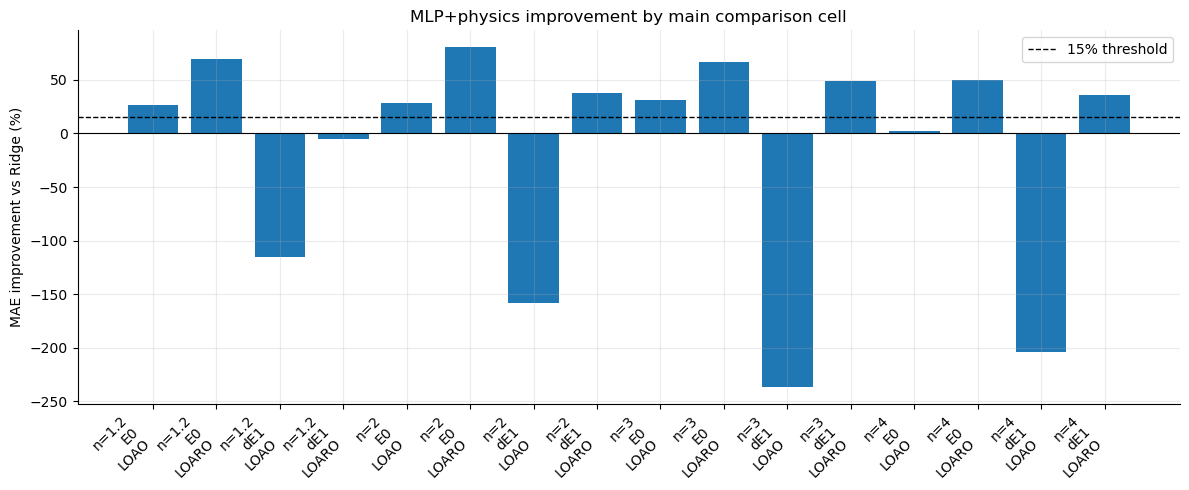

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\assets\mlp_ablation_improvement_by_cell.png


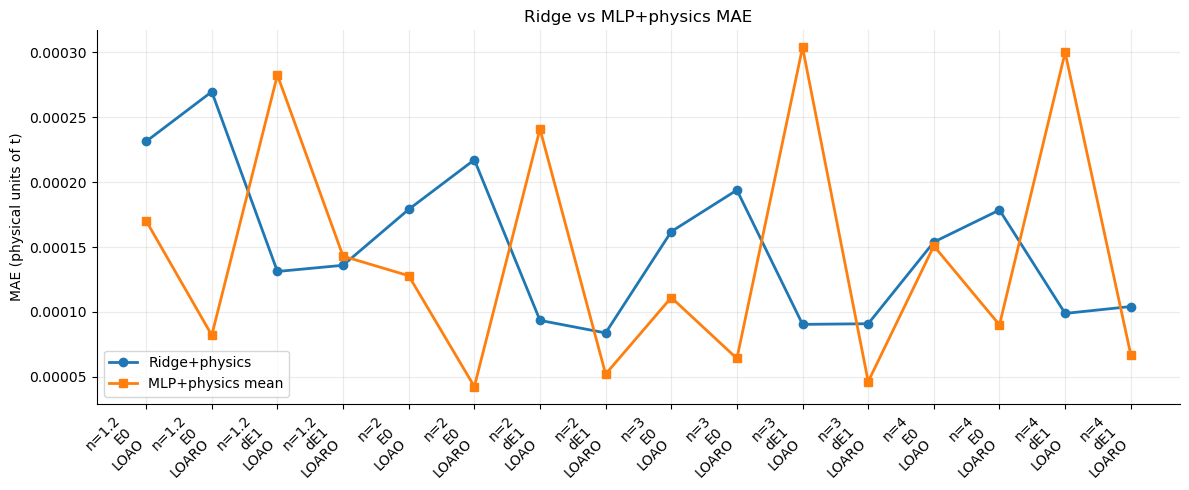

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\assets\mlp_ablation_ridge_vs_mlp_physics_mae.png


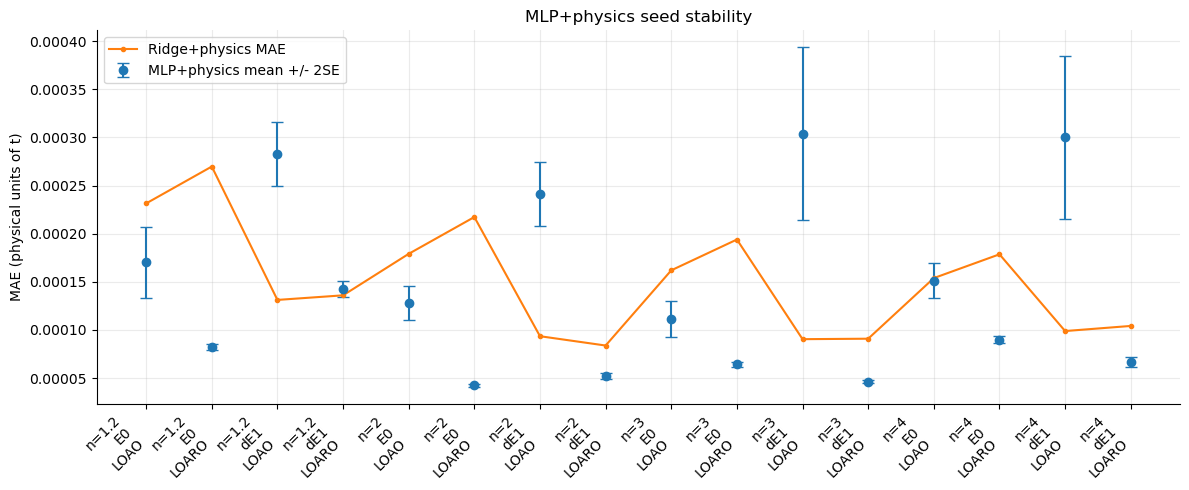

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\assets\mlp_ablation_seed_stability.png


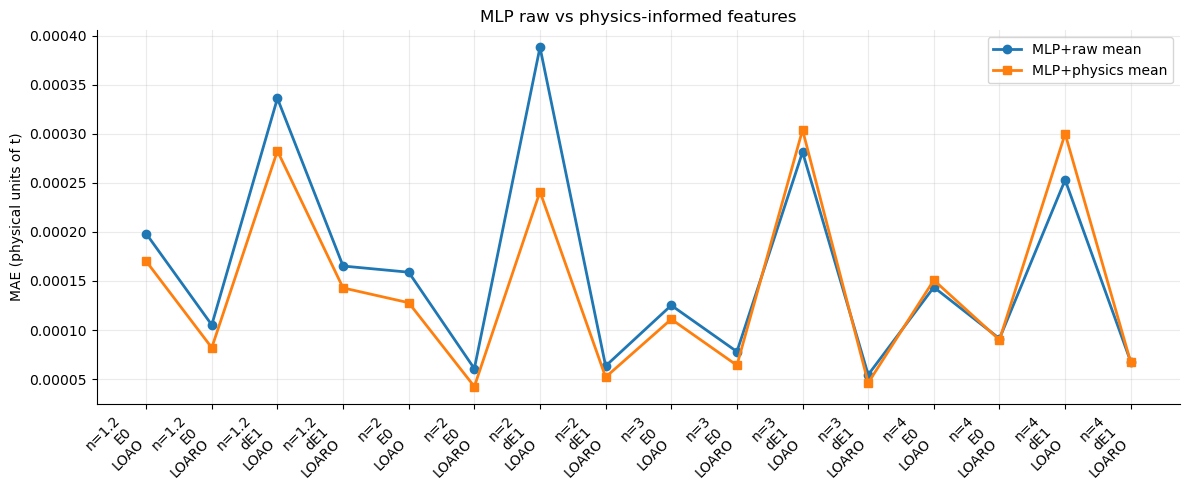

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\assets\mlp_raw_vs_physics_features.png


In [9]:
cell_labels = [f"n={row['n']:g}\n{row['target']}\n{row['protocol']}" for row in summary_rows]
x = np.arange(len(summary_rows))

fig, ax = plt.subplots(figsize=(12.0, 5.0))
ax.bar(x, [row["improvement_percent"] for row in summary_rows])
ax.axhline(MAIN_THRESHOLD_PERCENT, color="black", linestyle="--", linewidth=1, label="15% threshold")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cell_labels, rotation=45, ha="right")
ax.set_ylabel("MAE improvement vs Ridge (%)")
ax.set_title("MLP+physics improvement by main comparison cell")
ax.legend()
fig.tight_layout()
improvement_plot_path = ASSET_DIR / "mlp_ablation_improvement_by_cell.png"
fig.savefig(improvement_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {improvement_plot_path}")

fig, ax = plt.subplots(figsize=(12.0, 5.0))
ax.plot(x, [row["ridge_mae"] for row in summary_rows], marker="o", linewidth=2, label="Ridge+physics")
ax.plot(x, [row["mlp_physics_mae_mean"] for row in summary_rows], marker="s", linewidth=2, label="MLP+physics mean")
ax.set_xticks(x)
ax.set_xticklabels(cell_labels, rotation=45, ha="right")
ax.set_ylabel("MAE (physical units of t)")
ax.set_title("Ridge vs MLP+physics MAE")
ax.legend()
fig.tight_layout()
ridge_vs_mlp_plot_path = ASSET_DIR / "mlp_ablation_ridge_vs_mlp_physics_mae.png"
fig.savefig(ridge_vs_mlp_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {ridge_vs_mlp_plot_path}")

fig, ax = plt.subplots(figsize=(12.0, 5.0))
means = np.array([row["mlp_physics_mae_mean"] for row in summary_rows], dtype=float)
yerr = 2.0 * np.array([row["mlp_physics_mae_se"] for row in summary_rows], dtype=float)
ax.errorbar(x, means, yerr=yerr, marker="o", linestyle="none", capsize=4, label="MLP+physics mean +/- 2SE")
ax.plot(x, [row["ridge_mae"] for row in summary_rows], marker=".", linewidth=1.5, label="Ridge+physics MAE")
ax.set_xticks(x)
ax.set_xticklabels(cell_labels, rotation=45, ha="right")
ax.set_ylabel("MAE (physical units of t)")
ax.set_title("MLP+physics seed stability")
ax.legend()
fig.tight_layout()
seed_stability_plot_path = ASSET_DIR / "mlp_ablation_seed_stability.png"
fig.savefig(seed_stability_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {seed_stability_plot_path}")

fig, ax = plt.subplots(figsize=(12.0, 5.0))
ax.plot(x, [row["mlp_raw_mae_mean"] for row in summary_rows], marker="o", linewidth=2, label="MLP+raw mean")
ax.plot(x, [row["mlp_physics_mae_mean"] for row in summary_rows], marker="s", linewidth=2, label="MLP+physics mean")
ax.set_xticks(x)
ax.set_xticklabels(cell_labels, rotation=45, ha="right")
ax.set_ylabel("MAE (physical units of t)")
ax.set_title("MLP raw vs physics-informed features")
ax.legend()
fig.tight_layout()
raw_vs_physics_plot_path = ASSET_DIR / "mlp_raw_vs_physics_features.png"
fig.savefig(raw_vs_physics_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {raw_vs_physics_plot_path}")

## Conclusion

In [10]:
physics_better_count = int(sum(1 for row in summary_rows if row["mlp_physics_mae_mean"] < row["mlp_raw_mae_mean"]))
raw_better_count = len(summary_rows) - physics_better_count
mean_raw_mae = float(np.mean([row["mlp_raw_mae_mean"] for row in summary_rows]))
mean_physics_mae = float(np.mean([row["mlp_physics_mae_mean"] for row in summary_rows]))
physics_convergence_failures = int(sum(int(row["num_convergence_failures"]) for row in summary_rows))
all_mlp_failures = int(
    sum(
        int(row["num_convergence_failures"])
        for row in overall_rows
        if row["model"] == "mlp"
    )
)
max_improvement = max(summary_rows, key=lambda row: row["improvement_percent"])
min_improvement = min(summary_rows, key=lambda row: row["improvement_percent"])
loao_de1_rows = [row for row in summary_rows if row["protocol"] == "LOAO" and row["target"] == "dE1"]
loao_e0_rows = [row for row in summary_rows if row["protocol"] == "LOAO" and row["target"] == "E0"]
loao_de1_negative_count = int(sum(1 for row in loao_de1_rows if row["improvement_percent"] < 0.0))
loao_e0_positive_count = int(sum(1 for row in loao_e0_rows if row["improvement_percent"] > 0.0))
loao_de1_improvements = ", ".join(
    f"n={row['n']:g}: {row['improvement_percent']:.2f}%" for row in loao_de1_rows
)

decision_line = (
    "Pre-registered criterion met: MLP+physics shows robust improvement over Ridge+physics."
    if mlp_wins
    else "Pre-registered criterion not met: Ridge remains the preferred model."
)
robust_line = (
    "MLP+physics beats Ridge+physics robustly under the pre-registered rule."
    if mlp_wins
    else "MLP+physics does not beat Ridge+physics robustly under the pre-registered rule."
)
feature_line = (
    f"MLP+physics has lower mean MAE than MLP raw in {physics_better_count} of 16 cells; "
    f"MLP raw is lower in {raw_better_count} cells. Averaged over the 16 cells, "
    f"MLP raw mean MAE is {mean_raw_mae:.6g} and MLP+physics mean MAE is {mean_physics_mae:.6g}."
)
convergence_line = (
    f"MLP+physics has {physics_convergence_failures} convergence-failed folds across the main comparison cells; "
    f"all MLP fits together have {all_mlp_failures} convergence-failed folds."
)
loao_pattern_line = (
    f"The LOAO failure is concentrated in the dE1 target: {loao_de1_negative_count} of 4 n-classes "
    f"have negative improvement_percent for dE1 under LOAO ({loao_de1_improvements}). For E0 under LOAO, "
    f"MLP+physics improves over Ridge in {loao_e0_positive_count} of 4 n-classes."
)
interpretation_line = (
    "This suggests that the tiny MLP can add useful weak nonlinearity for E0 and aspect-ratio generalization, "
    "but does not robustly improve generalization to unseen size values for the level spacing dE1. Therefore Ridge "
    "remains preferred because it is simpler, interpretable, stable, and physically grounded."
)

conclusion = f"""
{decision_line}

- Success cells: {total_success_cells} of 16.
- LOAO success cells: {loao_success_cells} of 8.
- LOARO success cells: {loaro_success_cells} of 8.
- {robust_line}
- {loao_pattern_line}
- {interpretation_line}
- {feature_line}
- {convergence_line}
- Largest MLP+physics improvement: {max_improvement['improvement_percent']:.2f}% for `n={max_improvement['n']:g}`, target `{max_improvement['target']}`, protocol `{max_improvement['protocol']}`.
- Smallest MLP+physics improvement: {min_improvement['improvement_percent']:.2f}% for `n={min_improvement['n']:g}`, target `{min_improvement['target']}`, protocol `{min_improvement['protocol']}`.

Limitations: this is a tiny nonlinear ablation/control experiment on the fixed saved dataset. It does not establish data efficiency, does not show that the MLP discovered physical laws, does not replace direct Kwant calculations, and does not solve inverse design.
"""

display(Markdown(conclusion))


Pre-registered criterion not met: Ridge remains the preferred model.

- Success cells: 10 of 16.
- LOAO success cells: 3 of 8.
- LOARO success cells: 7 of 8.
- MLP+physics does not beat Ridge+physics robustly under the pre-registered rule.
- The LOAO failure is concentrated in the dE1 target: 4 of 4 n-classes have negative improvement_percent for dE1 under LOAO (n=1.2: -115.44%, n=2: -157.88%, n=3: -236.37%, n=4: -203.65%). For E0 under LOAO, MLP+physics improves over Ridge in 4 of 4 n-classes.
- This suggests that the tiny MLP can add useful weak nonlinearity for E0 and aspect-ratio generalization, but does not robustly improve generalization to unseen size values for the level spacing dE1. Therefore Ridge remains preferred because it is simpler, interpretable, stable, and physically grounded.
- MLP+physics has lower mean MAE than MLP raw in 13 of 16 cells; MLP raw is lower in 3 cells. Averaged over the 16 cells, MLP raw mean MAE is 0.000160673 and MLP+physics mean MAE is 0.000142147.
- MLP+physics has 0 convergence-failed folds across the main comparison cells; all MLP fits together have 0 convergence-failed folds.
- Largest MLP+physics improvement: 80.48% for `n=2`, target `E0`, protocol `LOARO`.
- Smallest MLP+physics improvement: -236.37% for `n=3`, target `dE1`, protocol `LOAO`.

Limitations: this is a tiny nonlinear ablation/control experiment on the fixed saved dataset. It does not establish data efficiency, does not show that the MLP discovered physical laws, does not replace direct Kwant calculations, and does not solve inverse design.
